In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datairis/IRIS_data.csv


In [2]:
!pip install pyspark

#Spark configuration

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer

spark = SparkSession.builder.master("local[2]").appName("Iris_Classification").getOrCreate()
sc = spark.sparkContext


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/11 19:58:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#Load dataset
df = spark.read.csv('/kaggle/input/datairis/IRIS_data.csv', header=True, inferSchema=True)

In [4]:
# View dataset structure
df.show(5)
df.printSchema()

+------------+-----------+------------+-----------+-----------+
|sepal_length|sepal_width|petal_length|petal_width|    species|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
+------------+-----------+------------+-----------+-----------+
only showing top 5 rows

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



In [5]:
df.count()

150

In [6]:
# Check total number of rows
total_rows = df.count()
print("Total rows in dataset:", total_rows)

Total rows in dataset: 150


In [7]:

# Encode the species column
indexer = StringIndexer(inputCol="species", outputCol="label")

df = indexer.fit(df).transform(df)

df.show(5)

+------------+-----------+------------+-----------+-----------+-----+
|sepal_length|sepal_width|petal_length|petal_width|    species|label|
+------------+-----------+------------+-----------+-----------+-----+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|  0.0|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|  0.0|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|  0.0|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|  0.0|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|  0.0|
+------------+-----------+------------+-----------+-----------+-----+
only showing top 5 rows



   Remove original species column(not necessary)
df = df.drop("species")

In [8]:
df.select("species", "label").distinct().show()

+---------------+-----+
|        species|label|
+---------------+-----+
|    Iris-setosa|  0.0|
| Iris-virginica|  2.0|
|Iris-versicolor|  1.0|
+---------------+-----+



In [9]:
df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|   50|
|  1.0|   50|
|  2.0|   50|
+-----+-----+



In [10]:
# Assemble feature columns
assembler = VectorAssembler(inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"], outputCol="features")
df = assembler.transform(df).select("features", "label")
df.show(5)

+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows



Machine learning algorithms cannot operate directly on text or categorical labels. They rely on numerical computations such as addition, multiplication, and optimization.

VectorAssembler:It combines multiple feature columns into one vector column:

Categorical labels must be encoded into numerical format because machine learning algorithms operate on numeric data and cannot process string labels. In Spark ML, labels are required to be numeric for loss computation and model training.

Assembling features into a single vector standardizes the input format required by Spark ML algorithms, improves computational efficiency, and enables scalable, pipeline-based machine learning on high-dimensional data.

Exercise 2: Train a Decision Tree Classifier
Task:
1. Split the dataset into training and testing sets (e.g., 70% training, 30% testing).
2. Train a Decision Tree model on the training data.
3. Use the trained model to predict the labels for the test data.
4. Evaluate the model using accuracy, precision, recall, and F1-score.

In [11]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression

# Split data
train_data, test_data = df.randomSplit([0.7, 0.3])

In [12]:
# Train Decision Tree model
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")
dt_model = dt.fit(train_data)


# Train Logistic Regression model
lr = LogisticRegression(labelCol="label", featuresCol="features")
lr_model = lr.fit(train_data)


In [13]:
# Make predictions DT
dt_predictions = dt_model.transform(test_data)

# Make predictions LG
lr_predictions = lr_model.transform(test_data)

In [14]:
# Count rows in each split
train_count = train_data.count()
test_count = test_data.count()



In [15]:
print("Training rows:", train_count)
print("Testing rows:", test_count)




Training rows: 102
Testing rows: 48


In [16]:
# Verify split percentages
print("Training percentage:", train_count / total_rows)
print("Testing percentage:", test_count / total_rows)

Training percentage: 0.68
Testing percentage: 0.32


In [17]:
# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Calculate metrics :DT
dt_accuracy = evaluator.evaluate(dt_predictions, {evaluator.metricName: "accuracy"})
dt_precision = evaluator.evaluate(dt_predictions, {evaluator.metricName: "weightedPrecision"})
dt_recall = evaluator.evaluate(dt_predictions, {evaluator.metricName: "weightedRecall"})
dt_f1 = evaluator.evaluate(dt_predictions, {evaluator.metricName: "f1"})
print(f"Decision Tree - Accuracy: {dt_accuracy}, Precision: {dt_precision}, Recall: {dt_recall}, F1: {dt_f1}")


# Calculate metrics: LR
lr_accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
lr_precision = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedPrecision"})
lr_recall = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedRecall"})
lr_f1 = evaluator.evaluate(lr_predictions, {evaluator.metricName: "f1"})

print(f"Logistic Regression - Accuracy: {lr_accuracy}, Precision: {lr_precision}, Recall: {lr_recall}, F1: {lr_f1}")





Decision Tree - Accuracy: 0.9166666666666666, Precision: 0.9351851851851851, Recall: 0.9166666666666667, F1: 0.9159226190476191
Logistic Regression - Accuracy: 0.9375, Precision: 0.9485294117647058, Recall: 0.9375, F1: 0.9372914349276975


In [18]:
from pyspark.sql import Row

metrics_data = [
    Row(Model="Decision Tree",
        Accuracy=dt_accuracy,
        Precision=dt_precision,
        Recall=dt_recall,
        F1=dt_f1),

    Row(Model="Logistic Regression",
        Accuracy=lr_accuracy,
        Precision=lr_precision,
        Recall=lr_recall,
        F1=lr_f1)
]

metrics_df = spark.createDataFrame(metrics_data)
metrics_df.show(truncate=False)#Prevents Spark from cutting off long text values and Ensures full column contents are visible


+-------------------+------------------+------------------+------------------+------------------+
|Model              |Accuracy          |Precision         |Recall            |F1                |
+-------------------+------------------+------------------+------------------+------------------+
|Decision Tree      |0.9166666666666666|0.9351851851851851|0.9166666666666667|0.9159226190476191|
|Logistic Regression|0.9375            |0.9485294117647058|0.9375            |0.9372914349276975|
+-------------------+------------------+------------------+------------------+------------------+



Accuracy — “How often is the model right?”
Accuracy tells you:Out of all predictions, how many did the model get correct?

Pecision — “When the model says X, is it correct?”
Precision tells you:Of the items the model predicted as a certain class, how many were actually that class?

Recall — “Did the model find everything it should?”
Recall tells you: Of all the actual items in a class, how many did the model correctly identify?

F1-score — “How good is the balance?”
Shows a balance between precision and recall.:A single score that says how well the model avoids both false alarms and missed cases

Exercise 3: Train a Logistic Regression Classifier
Task:
1. Train a Logistic Regression model on the same training data.
2. Use the model to predict the test data labels.
3. Evaluate the model using accuracy, precision, recall, and F1-score.
This part is added to the code above

Exercise 4: Visualise the Confusion Matrix for Both Models
Task:
1. Generate a confusion matrix for both the Decision Tree and Logistic Regression models.
2. Visualise the confusion matrices using a heatmap to better understand model performance.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.mllib.evaluation import MulticlassMetrics

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


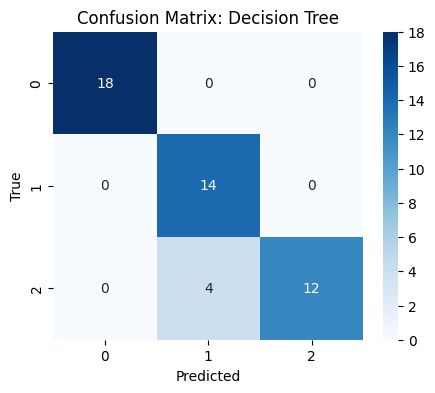

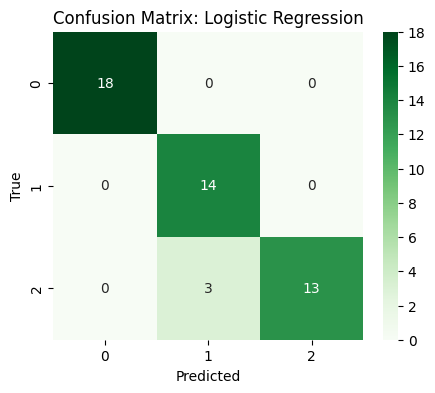

In [20]:
# Decision Tree confusion matrix
dt_preds_and_labels = dt_predictions.select("prediction", "label").rdd
dt_metrics = MulticlassMetrics(dt_preds_and_labels)
dt_confusion_matrix = dt_metrics.confusionMatrix().toArray()
# Logistic Regression confusion matrix
lr_preds_and_labels = lr_predictions.select("prediction", "label").rdd
lr_metrics = MulticlassMetrics(lr_preds_and_labels)
lr_confusion_matrix = lr_metrics.confusionMatrix().toArray()
# Plot Decision Tree confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(dt_confusion_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Plot Logistic Regression confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(lr_confusion_matrix, annot=True, fmt=".0f", cmap="Greens")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()